# ANALYTICS & VISUALIZATION


# 1. Import Required Libraries

In this notebook, we create visual analytics and presentation-ready charts for both:

- Demand Prediction Model
- Revenue Forecast Model

These charts help explain model performance clearly and improve report quality.

This notebook focuses on visualization, presentation, and business insights.

In [1]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

plt.style.use("default")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


# 2. Load Dataset and Models

We load:

- final feature engineered dataset
- best demand model
- best revenue model

This allows us to create prediction charts and business analytics for both models.

In [2]:
# 2. LOAD DATASET + MODELS

file_path = "../data/processed/final_feature_engineered_dataset.csv"

df = pd.read_csv(file_path)

best_demand_model = joblib.load(
    "../models/best_demand_prediction_model.pkl"
)

best_revenue_model = joblib.load(
    "../models/best_revenue_forecast_model.pkl"
)

print("Dataset and models loaded successfully")

Dataset and models loaded successfully


# 3. Select Features

We select the same important features used during model training.

This ensures predictions are accurate and consistent with previous notebooks.

In [3]:
# 3. SELECT FEATURES

feature_columns = [
    "product_encoded",
    "category_encoded",
    "unit_price",
    "month",
    "day",
    "day_of_week",
    "is_weekend",
    "rolling_avg_qty",
    "previous_qty",
    "lag_1",
    "lag_2",
    "rolling_avg_7",
    "rolling_avg_30"
]

X = df[feature_columns]

print("Features selected successfully")

Features selected successfully


# 4. Revenue Forecast Graph

This chart shows predicted revenue compared with actual revenue.

It helps visualize how well the revenue forecasting model performs.

This is one of the strongest charts for your final report.

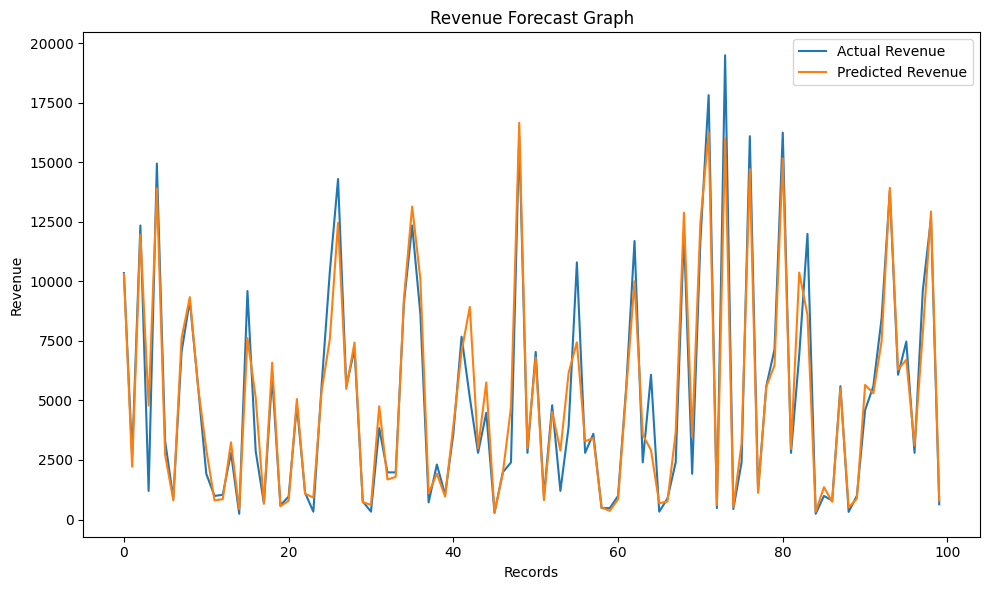

In [4]:
# 4. REVENUE FORECAST GRAPH

y_revenue = df["revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_revenue,
    test_size=0.20,
    random_state=42
)

revenue_predictions = best_revenue_model.predict(X_test)

plt.figure(figsize=(10, 6))

plt.plot(
    y_test.values[:100],
    label="Actual Revenue"
)

plt.plot(
    revenue_predictions[:100],
    label="Predicted Revenue"
)

plt.title("Revenue Forecast Graph")
plt.xlabel("Records")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Demand Prediction Graph

This chart shows predicted demand compared with actual demand.

It helps visualize how accurately the model predicts product sales quantity.

This is very useful for inventory forecasting presentations.

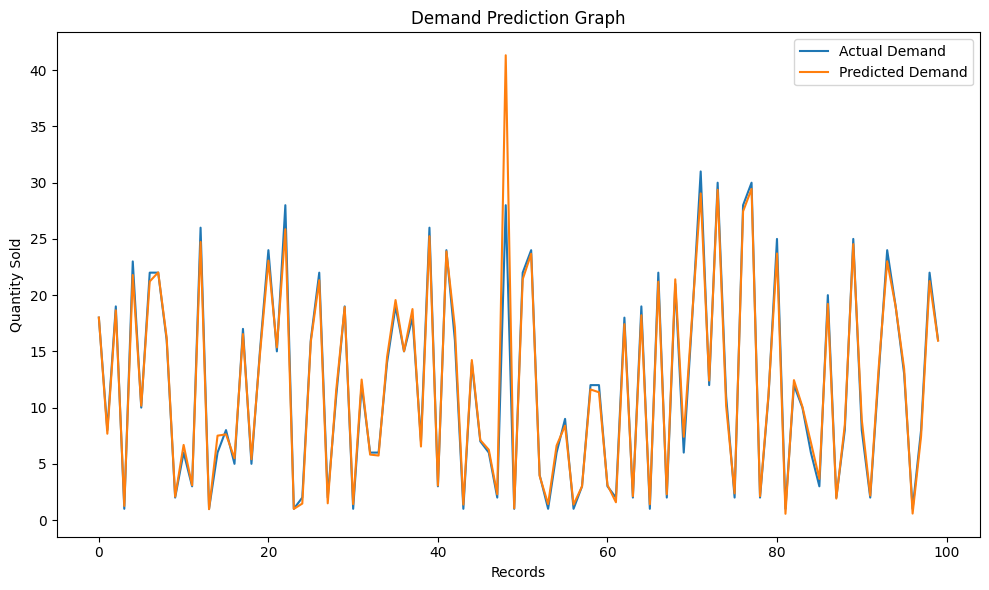

In [5]:
# 5. DEMAND PREDICTION GRAPH

y_demand = df["quantity_sold"]

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X,
    y_demand,
    test_size=0.20,
    random_state=42
)

demand_predictions = best_demand_model.predict(X_test_d)

plt.figure(figsize=(10, 6))

plt.plot(
    y_test_d.values[:100],
    label="Actual Demand"
)

plt.plot(
    demand_predictions[:100],
    label="Predicted Demand"
)

plt.title("Demand Prediction Graph")
plt.xlabel("Records")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Product Performance Chart

This chart shows which products generate the highest total revenue.

It helps identify top-performing products and supports business decision-making.

This is a strong business analytics chart for your report.

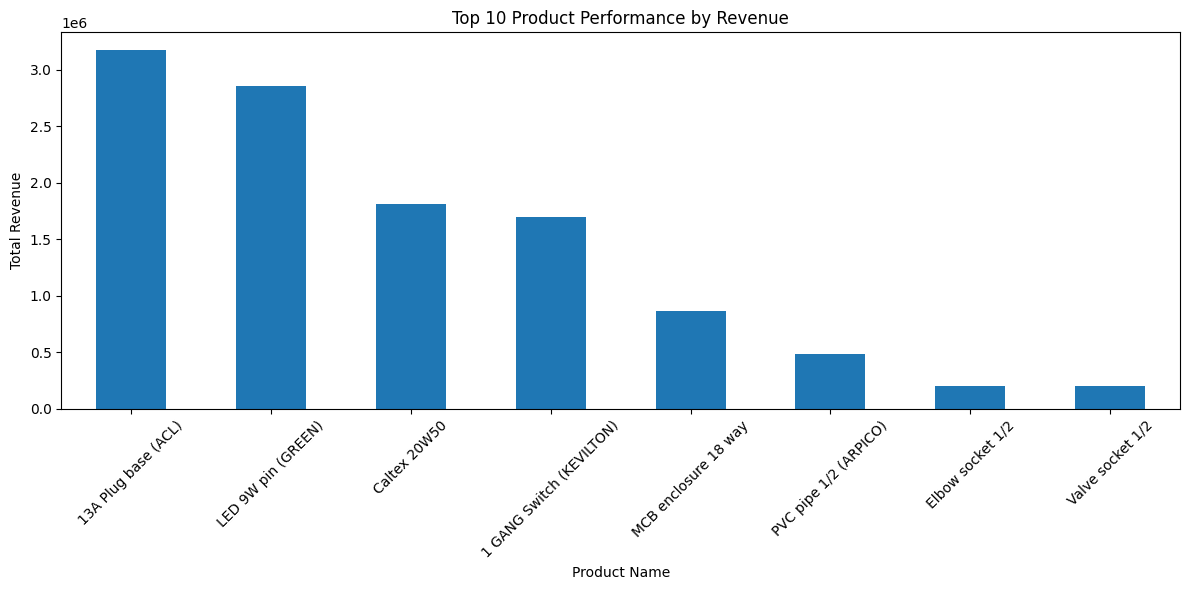

In [6]:
# 6. PRODUCT PERFORMANCE CHART

product_performance = (
    df.groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

product_performance.plot(kind="bar")

plt.title("Top 10 Product Performance by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Category-wise Sales Chart

This chart compares total revenue generated by each product category.

It helps identify which business category performs best.

This improves both analysis quality and presentation strength.

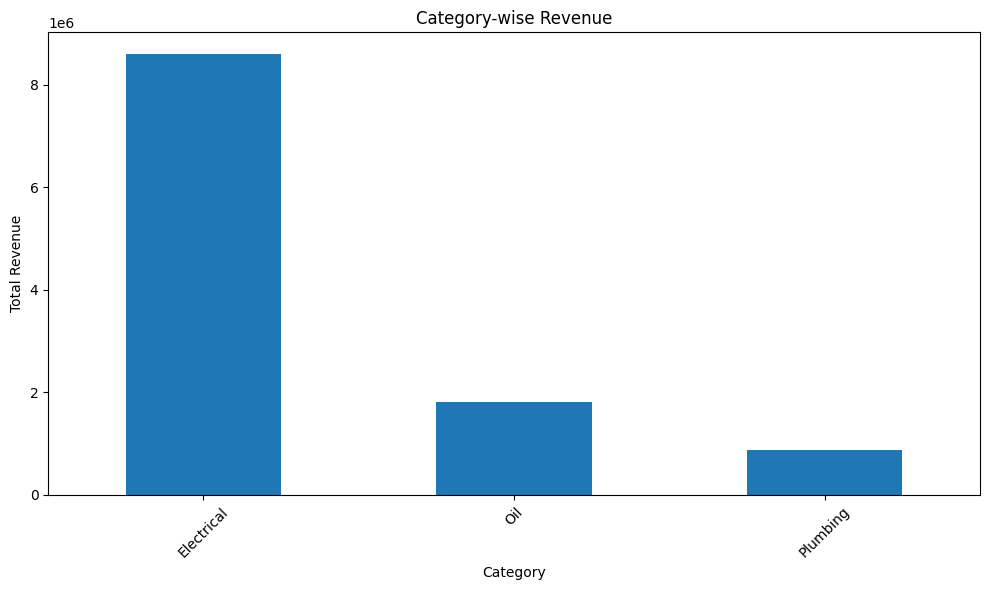

In [7]:
# 7. CATEGORY-WISE SALES CHART

category_sales = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Category-wise Revenue")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. Feature Importance Graph

This chart shows which features most strongly influence predictions.

It helps explain why the model makes certain decisions.

This is excellent for viva explanations and report quality.

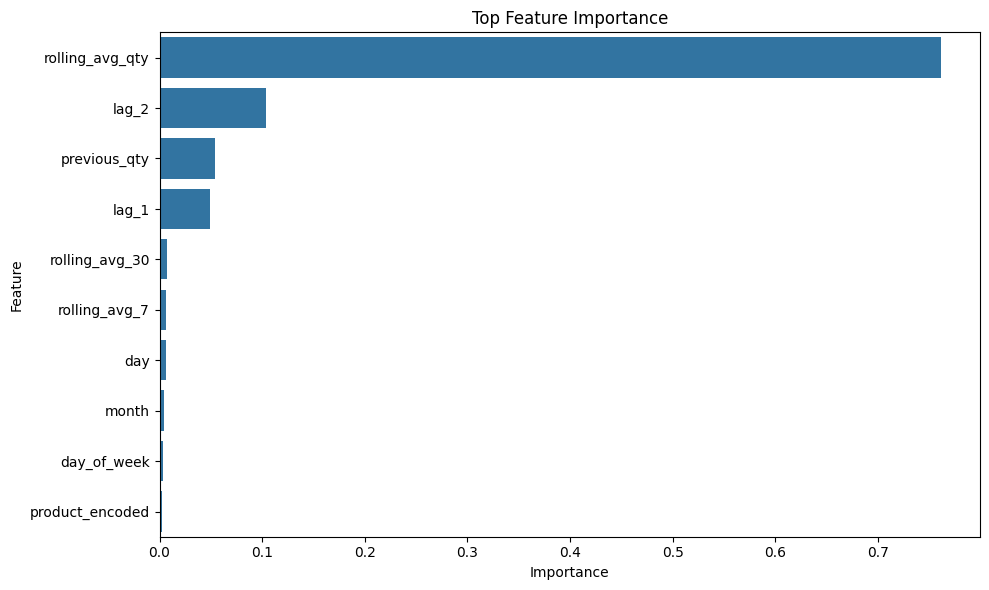

In [8]:
# 8. FEATURE IMPORTANCE GRAPH

feature_importance = pd.read_csv(
    "../reports/feature_importance.csv"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Feature Importance")
plt.tight_layout()
plt.show()

# 9. Actual vs Predicted — Revenue Model

This scatter plot compares actual revenue values with predicted revenue values.

If the model performs well, the points should stay close together.

This helps visually prove model quality.

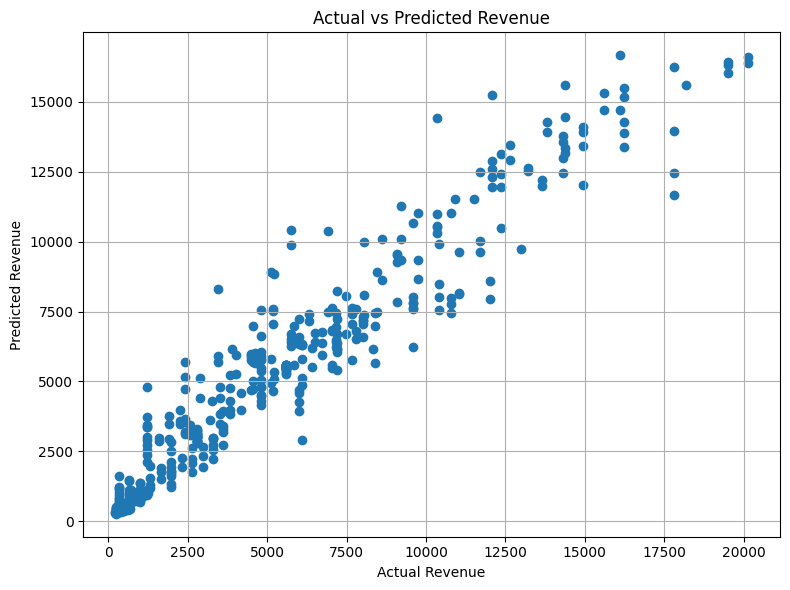

In [9]:
# 9. ACTUAL VS PREDICTED — REVENUE MODEL

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    revenue_predictions
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Actual vs Predicted — Demand Model

This scatter plot compares actual demand values with predicted demand values.

This helps visually confirm how well the demand model performs.

It is one of the strongest validation visuals.

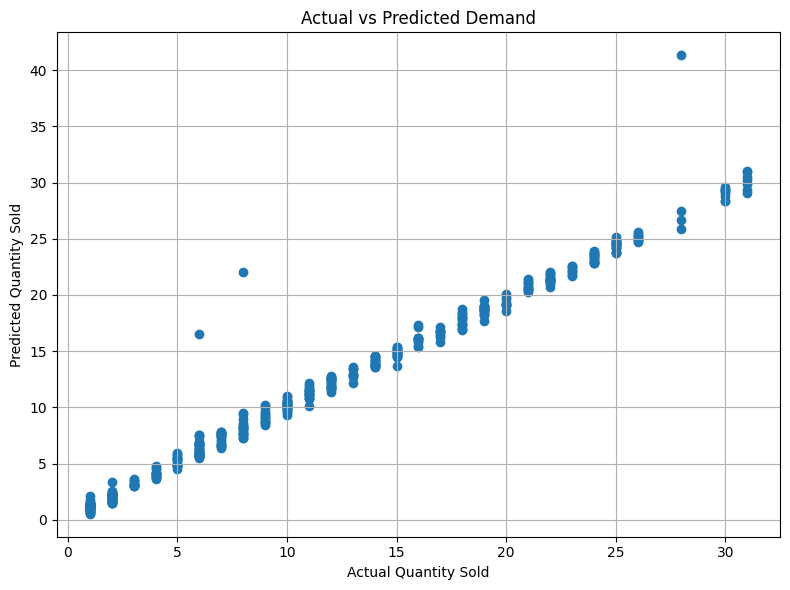

In [10]:
# 10. ACTUAL VS PREDICTED — DEMAND MODEL

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_d,
    demand_predictions
)

plt.xlabel("Actual Quantity Sold")
plt.ylabel("Predicted Quantity Sold")
plt.title("Actual vs Predicted Demand")

plt.grid(True)
plt.tight_layout()
plt.show()